In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm                                 # built in color maps
from sklearn.model_selection import train_test_split
import random

def points_within_circle(radius, center=(0, 0), number_of_points=100):
    center_x, center_y = center
    r = radius * np.sqrt(np.random.random((number_of_points,)))
    theta = np.random.random((number_of_points,)) * 2 * np.pi
    # print('r', r)
    # print('theta', theta)
    x = center_x + r * np.cos(theta)  # use cosine to find x values
    y = center_y + r * np.sin(theta)  # use sine to find y values
    # print('x', x)
    # print('y', y)
    return x, y

oranges_x, oranges_y = points_within_circle(1.6, (5, 2), 100)
lemons_x, lemons_y = points_within_circle(1.9, (2, 5), 100)

oranges = list(zip(oranges_x, oranges_y))
lemons = list(zip(lemons_x, lemons_y))

# labelling oranges with 0 and lemons with 1:
labelled_data = list(zip(oranges + lemons, [0] * len(oranges) + [1] * len(lemons)))
random.shuffle(labelled_data)

data, labels = zip(*labelled_data)

res = train_test_split(data, labels, train_size=0.8, test_size=0.2, random_state=42)
train_data, test_data, train_labels, test_labels = res

class Perceptron:
    def __init__(self, weights, learning_rate=0.1):
        """
        'weights' can be a numpy array, list or a tuple with the actual values of the weights. The number of input
        values is indirectly defined by the length of 'weights'
        """
        self.weights = np.array(weights)
        self.learning_rate = learning_rate
        # print('weights , learning_rate', weights, learning_rate)

    @staticmethod
    def unit_step_function(x):
        if x < 0:
            return 0
        else:
            return 1

    def __call__(self, in_data):
        weighted_input = self.weights * in_data
        weighted_sum = weighted_input.sum()
        # print('in_data, weighted_input, weighted_sum', in_data, weighted_input, weighted_sum)
        return Perceptron.unit_step_function(weighted_sum)

    def adjust(self, target_result, calculated_result, in_data):
        if type(in_data) != np.ndarray:
            in_data = np.array(in_data)      #
        error = target_result - calculated_result
        if error != 0:
            correction = error * in_data * self.learning_rate
            self.weights += correction
            # print(target_result, calculated_result, error, in_data, correction, self.weights)

    """
    A static method can be called either on the class (such as P.evaluate()) or on an instance (such as P().evaluate()). 
    Moreover, they can be called as regular functions (such as evaluate()).
    """
    @staticmethod
    def evaluate(data, labels):
        evaluation = Counter()
        for index in range(len(data)):
            # print('Evaluation index = ', index)
            label = int(round(p(data[index]), 0))
            if label == labels[index]:
                evaluation["correct"] += 1
            else:
                evaluation["wrong"] += 1
        return evaluation


In [56]:
p = Perceptron(weights=[0.1, 0.1], learning_rate=0.3)

number_of_colors = 7
colors = cm.rainbow(np.linspace(0, 1, number_of_colors))
colors

array([[5.00000000e-01, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [1.70588235e-01, 4.94655843e-01, 9.66718404e-01, 1.00000000e+00],
       [1.66666667e-01, 8.66025404e-01, 8.66025404e-01, 1.00000000e+00],
       [5.03921569e-01, 9.99981027e-01, 7.04925547e-01, 1.00000000e+00],
       [8.33333333e-01, 8.66025404e-01, 5.00000000e-01, 1.00000000e+00],
       [1.00000000e+00, 4.94655843e-01, 2.55842778e-01, 1.00000000e+00],
       [1.00000000e+00, 1.22464680e-16, 6.12323400e-17, 1.00000000e+00]])

1 0 -1.687679170082086 [-1.49458147 -0.88558388] (5.3152715830177675, 3.285279614356711)
3 1 1.7239528326655267 [-1.32743225  0.76999337] (0.5571640892158409, 5.5185908414938245)
8 2 0.36968627227175754 [-0.68840839  1.86214215] (2.1300795270272177, 3.640495940961366)
16 3 1.7978011248607186 [-1.87631715  1.04367337] (3.959695870049784, 2.728229282052247)
28 4 0.5945065629725407 [-1.18347843  1.99069028] (2.3094623906928566, 3.1567230334596452)
39 5 2.22764018100111 [-2.55668656  1.14771074] (4.577360425716911, 2.809931784729993)
40 6 0.8440903915066429 [-1.79841518  2.13059549] (2.52757127506597, 3.2762824896262774)


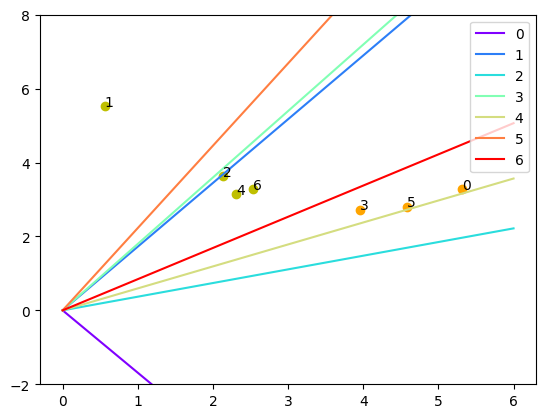

In [57]:
X = np.arange(0, 7)

fig, ax = plt.subplots()

ax.set_xticks(range(8))
ax.set_ylim([-2, 8])

counter = 0
for index in range(len(train_data)):
    old_weights = p.weights.copy()
    p.adjust(train_labels[index], p(train_data[index]), train_data[index])

    if not np.array_equal(old_weights, p.weights):
        color = "orange" if train_labels[index] == 0 else "y"

        ax.scatter(train_data[index][0], train_data[index][1], color=color)
        ax.annotate(str(counter), (train_data[index][0], train_data[index][1]))

        m = -p.weights[0] / p.weights[1]
        print(index, counter, m, p.weights, train_data[index])
        ax.plot(X, m * X, label=str(counter), color=colors[counter])
        counter += 1

ax.legend(loc='upper right')
plt.show()

In [ ]:
"""
Each of the points in the diagram above cause a change in the weights. We see them numbered in the order of
their appearance and the corresponding straight line. This way we can see how the networks "learns".
"""